## relate subjetc specific GMs to their behavior

1. correlate GMs to average GMs - relation to gamma (probit model)? --> no
2. 

In [1]:
import numpy as np
import nilearn.plotting as nplt
import nibabel as nib
import matplotlib.pyplot as plt
import os.path as op
from  nilearn.datasets import fetch_surf_fsaverage
from os import listdir
import seaborn as sns   
import pandas as pd
from utils_02 import get_GMmargulies_cmap
fsaverage = fetch_surf_fsaverage()

bids_folder = '/Volumes/mrenkeED/data/ds-stressrisk'
grad_folder = 'derivatives/gradients'
plot_folder_name = '/Users/mrenke/data/ds-stressrisk/plots_and_ims/gradients123_reordMaskFlip'
subList = [f[4:6] for f in listdir(op.join(bids_folder, grad_folder)) if f[0:4] == 'sub-' and len(f)==6]

specification = '_reordMaskFlip'
cmap = get_GMmargulies_cmap()

240318-13:40:35,49 nipype.utils WARNING:
	 A newer version (1.8.4) of nipy/nipype is available. You are using 1.8.3


In [2]:
# behavioral data
behavSummary_path ='/Users/mrenke/data/ds-stressrisk/interim_sum_data/'
file = 'subjectwise_gamma.tsv'#'subwise_seswise_n1_evidence_sd.csv' # gamma - only ses 1, all subjects
df_behav = pd.read_csv(op.join(behavSummary_path, file), sep='\t')
df_behav.head()

,subject,gamma
0,1,2.978560
1,2,2.707927
2,3,1.818231
3,4,2.106312
4,5,2.737986


### old alignemnt way, excluded subs ...


In [2]:
gradInsp_subList = pd.read_csv('/Users/mrenke/data/ds-stressrisk/interim_sum_data/gradient_inspection_list.csv')

cleanGM_subList = gradInsp_subList[gradInsp_subList['Order'] == '1']['Subject'].to_list()
cleanGM_subList = [int(x) for x in cleanGM_subList]
cleanGM_subList = ["{:02d}".format(x) for x in cleanGM_subList]

In [6]:
from utils import npFileTofs5Gii

sub = 'average_cmunfil_01'
specification = '_noParcel_aligned-marg'
npFileTofs5Gii(sub,1, specification=specification,bids_folder=bids_folder)

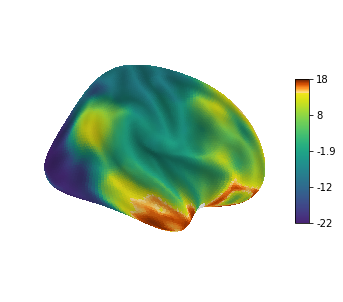

In [15]:
hemi = 'R'
grad_n = 1
file = f'sub-average_cmunfil_01_ses-1_task-risk_space-fsaverage5_hemi-{hemi}_grad{grad_n}_noParcel_aligned-marg.surf.gii'
ref_g1_hR = nib.load(op.join(bids_folder, grad_folder, f'sub-average_cmunfil_01/ses-1/{file}')).agg_data()

fsaverage = fetch_surf_fsaverage()

nplt.plot_surf(surf_mesh= fsaverage.infl_right, surf_map= ref_g1_hR, # infl_right # pial_right
               view= 'medial',cmap=cmap, colorbar=True,
               bg_map=fsaverage.sulc_right, bg_on_data=True,darkness=0.5,
               )
plt.show()

In [50]:
space = 'fsaverage5'

hemi = 'R'
grad_n = 1
file = f'sub-average_cmunfil_01_ses-1_task-risk_space-fsaverage5_hemi-{hemi}_grad{grad_n}_noParcel_aligned-marg.surf.gii'
ref_g1_hR = nib.load(op.join(bids_folder, grad_folder, f'sub-average_cmunfil_01/ses-1/{file}')).agg_data()

df_comb = pd.DataFrame()
for sub in cleanGM_subList:
    gm1 = nib.load(op.join(bids_folder,grad_folder,f'sub-{sub}','ses-1',f'sub-{sub}_ses-1_task-risk_space-{space}_hemi-{hemi}_grad{grad_n}{specification}.surf.gii')).agg_data()
    nonNan_ind = ~np.isnan(gm1)
    cor = np.corrcoef(ref_g1_hR[nonNan_ind], gm1[nonNan_ind])
    df = pd.DataFrame(data={'subject':int(sub), 'cor':cor[(0,1)]}, index=[0])
    df_comb = pd.concat([df_comb, df],axis=0)   


In [51]:
df_comb = df_comb.join(df_behav.set_index('subject'), on='subject')

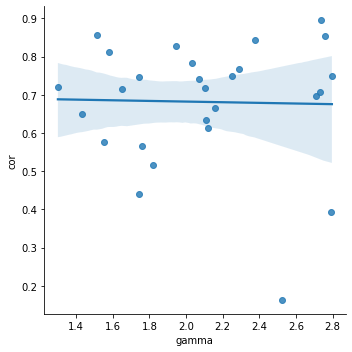

In [52]:
sns.lmplot(x='gamma', y='cor', data=df_comb)

## procrust alignment


In [ ]:
gm = np.load('/Volumes/mrenkeED/data/ds-stressrisk/derivatives/gradients/gm_av50_unfiltered_aligned-marg.npy')

from utils import get_basic_mask
from brainspace.utils.parcellation import map_to_labels

mask, labeling_noParcel = get_basic_mask()

grad = [None] * 3
for i, g in enumerate(gm.T): # gm.gradients_.T
    grad[i] = map_to_labels(g, labeling_noParcel, mask=mask, fill=np.nan)

sub ='average_cmunfil_01'
ses=1
specification = '_aligned-marg'
target_dir = op.join(bids_folder, 'derivatives', 'gradients', f'sub-{sub}', f'ses-{ses}')
np.save(op.join(target_dir,f'gradients{specification}.npy'), grad) # save all together


In [71]:
sub ='average_cmunfil_01'
gradients_average = np.load(op.join(bids_folder, 'derivatives', 'gradients', f'sub-{sub}', f'ses-1', f'gradients_aligned-marg.npy'))

specification = '__align-procrustes'
#gm_correlations_allSubs = pd.DataFrame(columns=['subject', 'grad1_cc', 'grad2_cc', 'grad3_cc'] )#[None] * len(subList)

gm_correlations_allSubs = pd.DataFrame()
for sub in subList:
    gradients_sub = np.load(op.join(bids_folder, 'derivatives', 'gradients', f'sub-{sub}', f'ses-1', f'gradients{specification}.npy'))
    gm_cor = []
    for n_grad in range(3):
        grad_sub = gradients_sub[n_grad]
        grad_average = gradients_average[n_grad]

        nonNan_ind = ~np.isnan(grad_sub)
        cor = np.corrcoef(grad_average[nonNan_ind], grad_sub[nonNan_ind])

        gm_cor.append(cor[(0,1)])

    df = pd.DataFrame(data={'subject':int(sub), 'grad1_cc':gm_cor[0], 'grad2_cc':gm_cor[1], 'grad3_cc': gm_cor[2]}, index=[0])
    
    gm_correlations_allSubs = pd.concat([gm_correlations_allSubs, df],axis=0)
gm_correlations_allSubs.set_index('subject', inplace=True)
gm_correlations_allSubs.sort_index(inplace=True)
gm_correlations_allSubs.head()

,grad1_cc,grad2_cc,grad3_cc
subject,,,
1,0.776206,0.812466,0.233774
2,0.820091,0.769662,0.271006
3,0.866420,0.898456,0.265448
4,0.815014,0.834454,0.589943
5,0.905390,0.886406,0.329177


In [82]:

df_behav = pd.read_csv('/Users/mrenke/data/ds-stressrisk/derivatives/cogmodels/param_estimates/bambi-1_subseswise_params.csv')
df_behav = df_behav[df_behav['session'] == 1]
df_comb = gm_correlations_allSubs.join(df_behav.set_index('subject'), on='subject')
df_comb.head()


,grad1_cc,grad2_cc,grad3_cc,session,rnp,gamma,intercept
subject,,,,,,,
1,0.776206,0.812466,0.233774,1,0.600260,2.892456,-1.481595
2,0.820091,0.769662,0.271006,1,0.545680,2.609244,-1.590322
3,0.866420,0.898456,0.265448,1,0.521614,1.813866,-1.181555
4,0.815014,0.834454,0.589943,1,0.407144,2.393254,-2.151008
5,0.905390,0.886406,0.329177,1,0.567051,2.764163,-1.573603


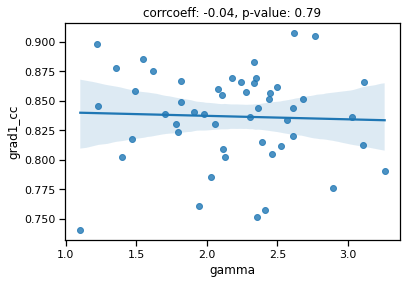

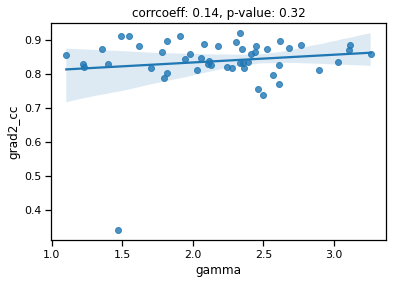

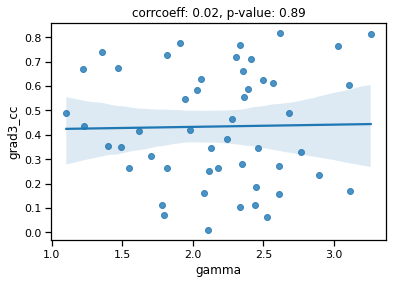

In [90]:
import pingouin as pg
sns.set_context('notebook')

for grad in range(1,4):
    plt.figure()
    cor = pg.corr(x=df_comb['gamma'], y=df_comb[f'grad{grad}_cc'])
    sns.regplot(x='gamma', y=f'grad{grad}_cc', data=df_comb).set_title(f'corrcoeff: {cor["r"].values[0]:.2f}, p-value: {cor["p-val"].values[0]:.2f}')


Text(0.5, 0.98, 'normal')

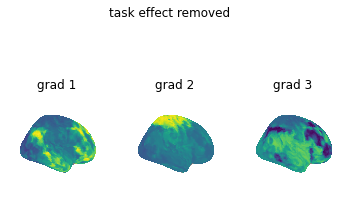

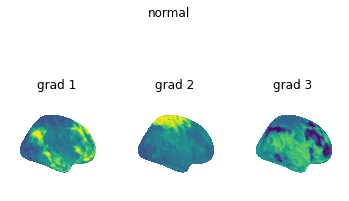

In [2]:
from utils_02 import plot_from_nparray
import numpy as np
import matplotlib.pyplot as plt


file = '/Volumes/mrenkeED/data/ds-stressrisk/derivatives/gradients/sub-01/ses-1/gradients__removed-taskeffect_align-procrustes.npy'
grad = np.load(file)
figure, axes =plot_from_nparray(grad)
figure.suptitle('task effect removed')

file = '/Volumes/mrenkeED/data/ds-stressrisk/derivatives/gradients/sub-01/ses-1/gradients__align-procrustes.npy'
grad = np.load(file)
figure, axes =plot_from_nparray(grad)
figure.suptitle('normal')
